In [29]:
# Mount the Google Drive to Google Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.6 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [6]:
# Training the model
!yolo task=segment \
    mode=train \
    model=yolov8n.pt \
    data=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowSegmentation/data.yaml \
    epochs=20 \
    imgsz=640 \
    batch=5 \
    project=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowSegmentation/TrainingResults \
    name=Training_Results

WARNING ⚠️ conflicting 'task=segment' passed with 'task=detect' model. Ignoring 'task=segment' and updating to 'task=detect' to match model.
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowSegmentation/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line

In [7]:
# Using the trained model to do segmentaion on Images
!yolo task=segment \
    mode=predict \
    model=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowSegmentation/TrainingResults/Training_Results/weights/best.pt \
    conf=0.55 \
    source=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImages

WARNING ⚠️ conflicting 'task=segment' passed with 'task=detect' model. Ignoring 'task=segment' and updating to 'task=detect' to match model.
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImages/test_pic_1.jpg: 640x640 1 cow_eat, 7.3ms
image 2/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImages/test_pic_2.jpg: 640x640 1 cow_rest, 10.3ms
image 3/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImages/test_pic_3.jpg: 640x640 1 cow_rest, 7.4ms
Speed: 356.5ms preprocess, 8.3ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [13]:
# Storing the segmented images in google drive
!cp -r /content/runs/detect/predict /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImagesSegmented

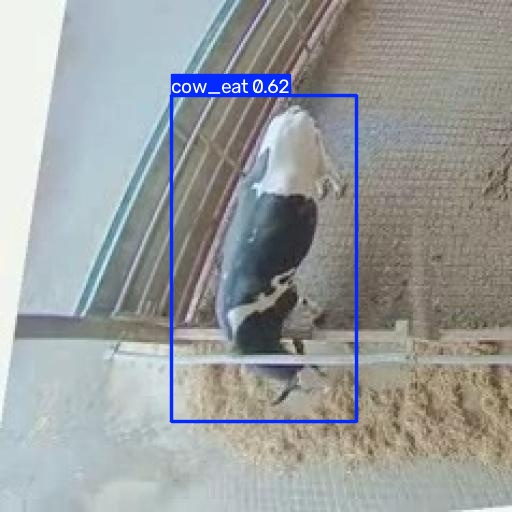

In [20]:
# Displaying one of the result
from IPython.display import Image
Image('/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestImagesSegmented/predict/test_pic_1.jpg')

In [22]:
# Using the trained model to do segmentaion on Videos
!yolo task=segment \
    mode=predict \
    model=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowSegmentation/TrainingResults/Training_Results/weights/best.pt \
    conf=0.55 \
    conf=0.55 \
    source=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideos

WARNING ⚠️ conflicting 'task=segment' passed with 'task=detect' model. Ignoring 'task=segment' and updating to 'task=detect' to match model.
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

video 1/1 (frame 1/18) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideos/test_video_1.mp4: 640x640 1 cow_eat, 7.7ms
video 1/1 (frame 2/18) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideos/test_video_1.mp4: 640x640 (no detections), 8.3ms
video 1/1 (frame 3/18) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideos/test_video_1.mp4: 640x640 1 cow_eat, 7.2ms
video 1/1 (frame 4/18) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideos/test_video_1.mp4: 640x640 1 cow_eat, 8.6ms
video 1/1 (frame 5/18) /content/drive/MyDrive/Video_Segmentation_Stu

In [24]:
# Storing the segmented videos in google drive
!cp -r /content/runs/detect/predict-2 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented

In [31]:
# Converting one of the videos to mp4 format for display
# (Natively segmented video is stored as .avi which our poor collab cannot play)
!ffmpeg -y -i /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/test_video_1.avi -vcodec libx264 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/converted_video.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [32]:
# Displaying one of the segmented videos
from IPython.display import Video

video_path = '/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/converted_video.mp4'

Video(video_path, embed=True, width=640)

Converting video to GIF...
MoviePy - Building file /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/converted_video.gif with imageio.


Displaying GIF...


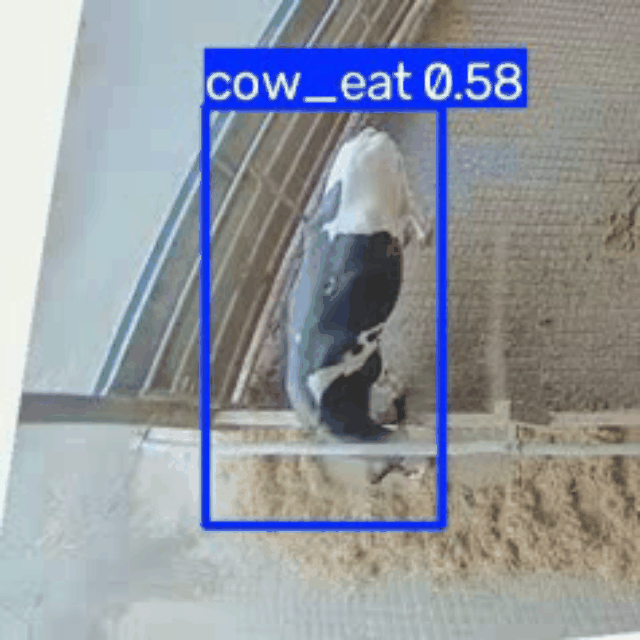

In [34]:
# To diplay the result as a gif because git won't let me play/embed the above code cell video there.

!pip install moviepy

from moviepy.editor import VideoFileClip
from IPython.display import Image, display

# Define paths
video_path = '/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/converted_video.mp4'
gif_path = '/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study03/CowTestVideosSegmented/converted_video.gif'

# Convert video to GIF
print("Converting video to GIF...")
clip = VideoFileClip(video_path)
clip = clip.resize(width=640)
clip.write_gif(gif_path, fps=10)

# Display the resulting GIF
print("Displaying GIF...")
display(Image(filename=gif_path, embed=True))